In [2]:
import yfinance as yf            # Mengimpor library yfinance untuk mengambil data saham dari Yahoo Finance
import pandas as pd              # Mengimpor pandas dengan alias pd, digunakan untuk manipulasi data berbentuk tabel (DataFrame)
import numpy as np               # Mengimpor numpy dengan alias np, digunakan untuk operasi numerik dan statistik
import matplotlib.pyplot as plt  # Mengimpor matplotlib.pyplot dengan alias plt, digunakan untuk membuat berbagai jenis visualisasi data (grafik garis, batang, scatter, dll.)

In [3]:
# Download data saham BBRI dari Yahoo Finance
# "BBRI.JK" adalah ticker Bank Rakyat Indonesia di Bursa Efek Indonesia (JK = Jakarta)
# Periode data dimulai dari 1 Januari 2020 sampai 31 Desember 2024
bbri = yf.download("BBRI.JK", start="2020-01-01", end="2024-12-31")

# Download data Indeks Harga Saham Gabungan (IHSG) dari Yahoo Finance
# "^JKSE" adalah ticker untuk IHSG
# Periode data sama, dari 1 Januari 2020 sampai 31 Desember 2024
ihsg = yf.download("^JKSE", start="2020-01-01", end="2024-12-31")


C:\Users\USER\AppData\Local\Temp\ipykernel_2100\4165091797.py:4: FutureWarning: YF.download() has changed argument auto_adjust default to True
  bbri = yf.download("BBRI.JK", start="2020-01-01", end="2024-12-31")
[*********************100%***********************]  1 of 1 completed
C:\Users\USER\AppData\Local\Temp\ipykernel_2100\4165091797.py:9: FutureWarning: YF.download() has changed argument auto_adjust default to True
  ihsg = yf.download("^JKSE", start="2020-01-01", end="2024-12-31")
[*********************100%***********************]  1 of 1 completed


In [4]:
# Mengambil hanya kolom 'Close' (harga penutupan harian) dari data BBRI
# Lalu mengganti nama kolom 'Close' menjadi 'BBRI' agar lebih mudah dibedakan
bbri_close = bbri[['Close']].rename(columns={'Close': 'BBRI'})

# Mengambil hanya kolom 'Close' dari data IHSG
# Lalu mengganti nama kolom 'Close' menjadi 'IHSG'
ihsg_close = ihsg[['Close']].rename(columns={'Close': 'IHSG'})


In [5]:
# Menggabungkan data harga penutupan BBRI dan IHSG menjadi satu DataFrame
# 'axis=1' artinya penggabungan dilakukan secara horizontal (berdampingan berdasarkan index/tanggal)
data = pd.concat([bbri_close, ihsg_close], axis=1)

# Menetapkan ulang nama kolom agar lebih rapi dan konsisten
data.columns = ['BBRI', 'IHSG']


In [6]:
# Menampilkan DataFrame 'data' untuk melihat hasil gabungan
# Data berisi dua kolom: harga penutupan BBRI dan IHSG dengan index berupa tanggal
data

,BBRI,IHSG
Date,,
2020-01-02,2960.843262,6283.581055
2020-01-03,2967.557129,6323.465820
2020-01-06,2933.987793,6257.402832
2020-01-07,2954.129150,6279.346191
2020-01-08,2940.701660,6225.686035
...,...,...
2024-12-20,3713.997803,6983.865234
2024-12-23,3851.214600,7096.444824
2024-12-24,3842.066895,7065.746094


In [7]:
# Menghitung log return harian untuk BBRI dan IHSG
# Rumus: ln(Pt / Pt-1), di mana Pt adalah harga hari ini dan Pt-1 adalah harga sebelumnya
# data.shift(1) menggeser data ke bawah 1 baris, sehingga harga hari ini bisa dibagi harga kemarin
returns = np.log(data / data.shift(1))

# Menampilkan 5 baris pertama hasil perhitungan log return
returns.head()

,BBRI,IHSG
Date,,
2020-01-02,NaN,NaN
2020-01-03,0.002265,0.006327
2020-01-06,-0.011377,-0.010502
2020-01-07,0.006841,0.003501
2020-01-08,-0.004556,-0.008582


In [8]:
# Menghitung rata-rata return harian dari BBRI dan IHSG
mean_return = returns.mean()

# Mengubah rata-rata return harian menjadi return tahunan
# Asumsi: dalam setahun ada sekitar 252 hari perdagangan (hari bursa)
annual_return = mean_return * 252  

# Menampilkan hasil return rata-rata tahunan
print("Return rata-rata tahunan:")
print(annual_return)


Return rata-rata tahunan:
BBRI    0.055028
IHSG    0.024850
dtype: float64


In [9]:
# Menghitung volatilitas harian (standar deviasi return harian) untuk BBRI dan IHSG
daily_vol = returns.std()

# Mengubah volatilitas harian menjadi volatilitas tahunan
# Rumus: σ_tahunan = σ_harian × √252
# 252 = jumlah hari perdagangan dalam setahun
annual_vol = daily_vol * np.sqrt(252)

# Menampilkan hasil volatilitas tahunan
print("Volatilitas tahunan:")
print(annual_vol)

Volatilitas tahunan:
BBRI    0.332132
IHSG    0.163829
dtype: float64


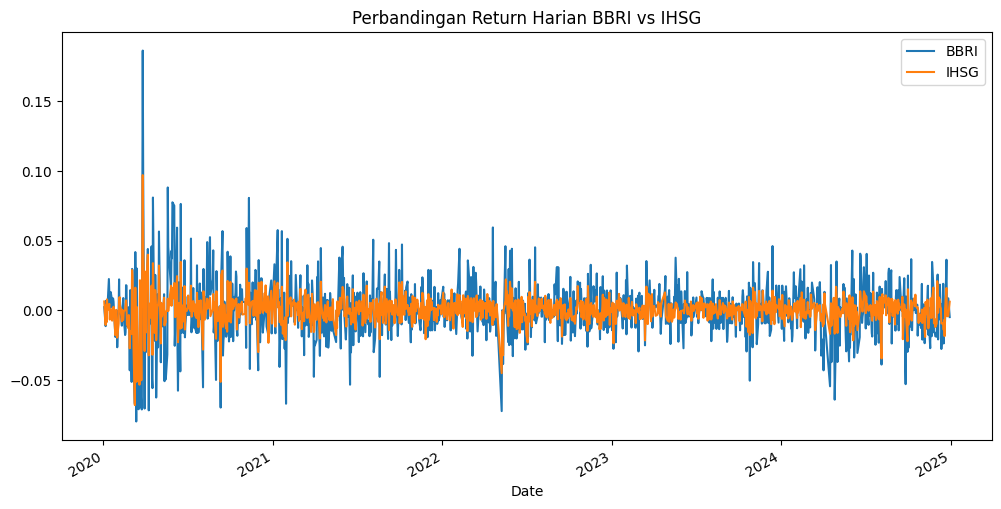

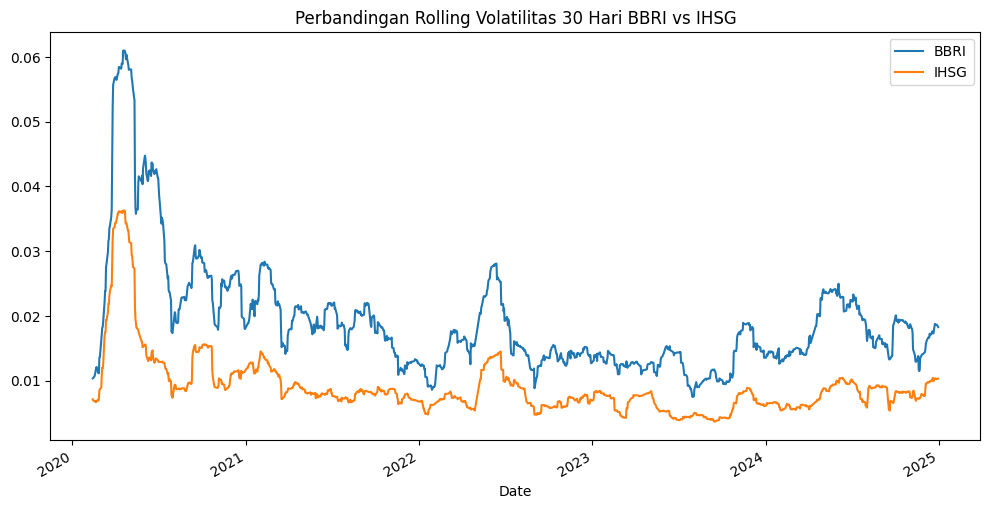

In [10]:
# 1. Membuat grafik perbandingan return harian BBRI dan IHSG
# returns.plot() langsung menampilkan dua garis (BBRI dan IHSG) dengan index tanggal di sumbu x
# figsize=(12,6) mengatur ukuran grafik agar lebih lebar
# title memberi judul pada grafik
returns.plot(figsize=(12,6), title="Perbandingan Return Harian BBRI vs IHSG")
plt.show()

# 2. Membuat grafik rolling volatilitas 30 hari
# returns.rolling(30).std() menghitung standar deviasi (volatilitas) dengan jendela bergerak sepanjang 30 hari
# Hasilnya dibandingkan antara BBRI dan IHSG
returns.rolling(30).std().plot(figsize=(12,6), title="Perbandingan Rolling Volatilitas 30 Hari BBRI vs IHSG")
plt.show()


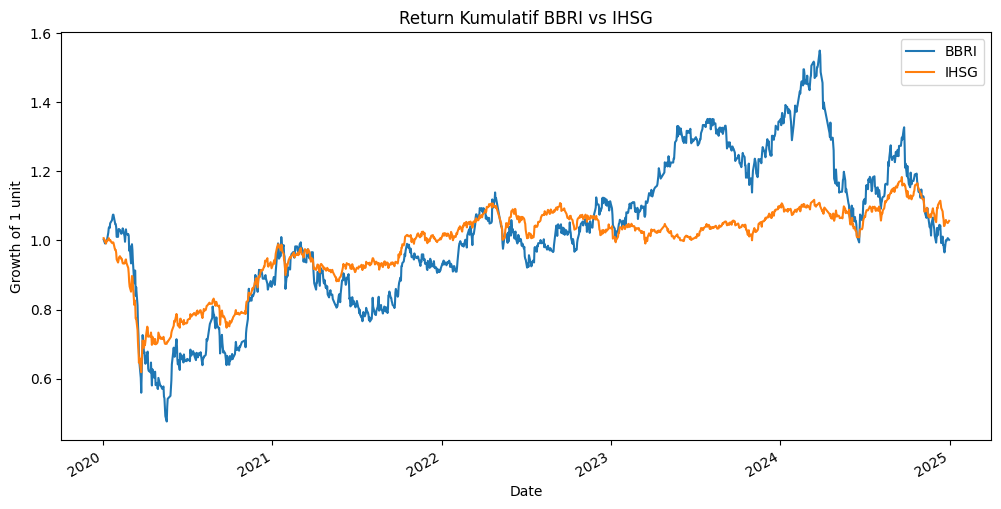

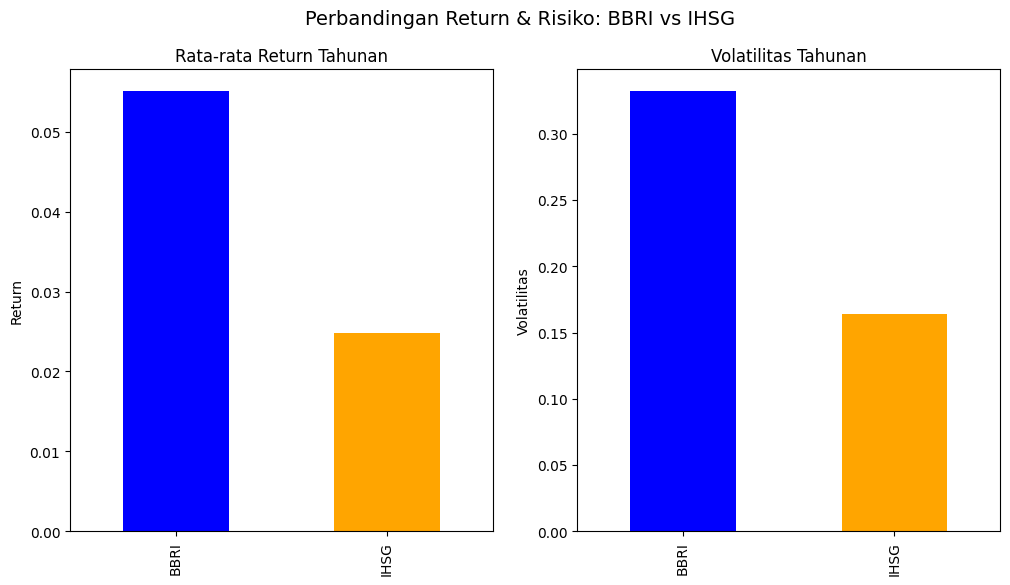

In [12]:


# === 1. Return kumulatif ===
# (1 + returns).cumprod() menghitung return kumulatif (akumulasi pertumbuhan nilai investasi)
# Misalnya jika investasikan 1 unit (Rp1) di awal periode, grafik menunjukkan perkembangannya dari waktu ke waktu
(1 + returns).cumprod().plot(figsize=(12,6))
plt.title("Return Kumulatif BBRI vs IHSG")
plt.ylabel("Growth of 1 unit")  # sumbu Y menunjukkan pertumbuhan investasi

# Simpan grafik ke file PNG
plt.savefig("return_kumulatif.png", dpi=300)  

plt.show()

# === 2. Bar chart rata-rata return & volatilitas ===

# Menghitung return tahunan rata-rata (annualized mean return)
avg_return = returns.mean() * 252  

# Menghitung volatilitas tahunan (annualized volatility)
volatility = returns.std() * (252**0.5)  

# Membuat 2 subplot berdampingan (1 baris, 2 kolom)
fig, ax = plt.subplots(1,2, figsize=(12,6))

# Grafik batang rata-rata return tahunan
avg_return.plot(kind='bar', ax=ax[0], color=['blue','orange'])
ax[0].set_title("Rata-rata Return Tahunan")
ax[0].set_ylabel("Return")

# Grafik batang volatilitas tahunan
volatility.plot(kind='bar', ax=ax[1], color=['blue','orange'])
ax[1].set_title("Volatilitas Tahunan")
ax[1].set_ylabel("Volatilitas")

# Menambahkan judul utama untuk kedua grafik
plt.suptitle("Perbandingan Return & Risiko: BBRI vs IHSG", fontsize=14)
plt.show()
